In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

In [3]:
df = pd.read_csv(r'C:\Users\PRIYA\OneDrive\Desktop\Priya Chauhan\Alpa IT\Startup_imbalanced_dataset_task\investments_VC.csv', encoding='latin1')
df.head()

,permalink,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,/organization/waywire,#waywire,http://www.waywire.com,|Entertainment|Politics|Social Media|News|,News,"17,50,000",acquired,USA,NY,New York City,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,/organization/tv-communications,&TV Communications,http://enjoyandtv.com,|Games|,Games,"40,00,000",operating,USA,CA,Los Angeles,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,/organization/rock-your-paper,'Rock' Your Paper,http://www.rockyourpaper.org,|Publishing|Education|,Publishing,"40,000",operating,EST,NaN,Tallinn,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,/organization/in-touch-network,(In)Touch Network,http://www.InTouchNetwork.com,|Electronics|Guides|Coffee|Restaurants|Music|i...,Electronics,"15,00,000",operating,GBR,NaN,London,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,/organization/r-ranch-and-mine,-R- Ranch and Mine,NaN,|Tourism|Entertainment|Games|,Tourism,"60,000",operating,USA,TX,Dallas,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 39 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   permalink             49438 non-null  object 
 1   name                  49437 non-null  object 
 2   homepage_url          45989 non-null  object 
 3   category_list         45477 non-null  object 
 4    market               45470 non-null  object 
 5    funding_total_usd    49438 non-null  object 
 6   status                48124 non-null  object 
 7   country_code          44165 non-null  object 
 8   state_code            30161 non-null  object 
 9   region                44165 non-null  object 
 10  city                  43322 non-null  object 
 11  funding_rounds        49438 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

(54294, 39)

In [5]:
#Check missing values
print(df.isnull().sum())

permalink                4856
name                     4857
homepage_url             8305
category_list            8817
 market                  8824
 funding_total_usd       4856
status                   6170
country_code            10129
state_code              24133
region                  10129
city                    10972
funding_rounds           4856
founded_at              15740
founded_month           15812
founded_quarter         15812
founded_year            15812
first_funding_at         4856
last_funding_at          4856
seed                     4856
venture                  4856
equity_crowdfunding      4856
undisclosed              4856
convertible_note         4856
debt_financing           4856
angel                    4856
grant                    4856
private_equity           4856
post_ipo_equity          4856
post_ipo_debt            4856
secondary_market         4856
product_crowdfunding     4856
round_A                  4856
round_B                  4856
round_C   

### Handling Null Values and Data Cleaning for EDA


In [6]:
# Clean and convert 'funding_total_usd' to numeric
df[' funding_total_usd '] = df[' funding_total_usd '].astype(str).str.replace(r'[$,]', '', regex=True)
df[' funding_total_usd '] = pd.to_numeric(df[' funding_total_usd '], errors='coerce')

# Verify the conversion and check for new NaNs introduced by 'coerce'
print("Data type of 'funding_total_usd' after conversion:", df[' funding_total_usd '].dtype)
print("Number of Null values in 'funding_total_usd' after conversion:", df[' funding_total_usd '].isnull().sum())

Data type of 'funding_total_usd' after conversion: float64
Number of Null values in 'funding_total_usd' after conversion: 13387


In [7]:
# Drop rows where 'permalink' or 'name' are null
original_rows = len(df)
df = df.dropna(subset=['permalink', 'name'])
print(f"Dropped {original_rows - len(df)} rows with null 'permalink' or 'name'.")

Dropped 4857 rows with null 'permalink' or 'name'.


In [8]:
# 1. Drop columns with too many missing values
missing_percentage = df.isnull().sum() / len(df) * 100
columns_to_drop = missing_percentage[missing_percentage > 50].index #Drop columns if null values are more than 50%
df = df.drop(columns=columns_to_drop, errors='ignore') # Use errors='ignore' in case columns are already dropped
print(f"Columns dropped due to high missing values: {list(columns_to_drop)}")

Columns dropped due to high missing values: []


In [9]:
# 2. Impute numerical columns with the median
for col in df.select_dtypes(include=np.number).columns:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"Imputed numerical column '{col}' with median: {median_val}")

Imputed numerical column ' funding_total_usd ' with median: 2000000.0
Imputed numerical column 'founded_year' with median: 2010.0


In [10]:
# 3. Impute categorical (i.e., object) columns with the mode
for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().any():
        mode_val = df[col].mode()[0]
        df[col] = df[col].fillna(mode_val)
        print(f"Imputed object column '{col}' with mode: {mode_val}")

Imputed object column 'homepage_url' with mode: http://app.thotz.co/
Imputed object column 'category_list' with mode: |Software|
Imputed object column ' market ' with mode:  Software 
Imputed object column 'status' with mode: operating
Imputed object column 'country_code' with mode: USA
Imputed object column 'state_code' with mode: CA
Imputed object column 'region' with mode: SF Bay Area
Imputed object column 'city' with mode: San Francisco
Imputed object column 'founded_at' with mode: 2012-01-01
Imputed object column 'founded_month' with mode: 2012-01
Imputed object column 'founded_quarter' with mode: 2012-Q1


In [11]:
# 4. Handle date columns conversion and imputation
date_cols_to_convert = ['founded_at', 'first_funding_at', 'last_funding_at']
for col in date_cols_to_convert:
    if col in df.columns:
        # Convert to datetime, coercing errors will turn invalid dates into NaT
        df[col] = pd.to_datetime(df[col], errors='coerce')
        if df[col].isnull().any():
            # If there are NaT values after conversion, impute with mode or a default date
            mode_date = df[col].mode()[0] if not df[col].mode().empty else pd.Timestamp('1970-01-01')
            df[col] = df[col].fillna(mode_date)
            print(f"Imputed date column '{col}' with mode date: {mode_date.date()}")

Imputed date column 'founded_at' with mode date: 2012-01-01
Imputed date column 'first_funding_at' with mode date: 2012-01-01
Imputed date column 'last_funding_at' with mode date: 2013-01-01


In [12]:
if 'founded_at' in df.columns:
    if 'founded_month' in df.columns:
        df['founded_month'] = df['founded_at'].dt.to_period('M').astype(str)
        print("Derived 'founded_month' from 'founded_at'.")
    if 'founded_quarter' in df.columns:
        df['founded_quarter'] = df['founded_at'].dt.to_period('Q').astype(str)
        print("Derived 'founded_quarter' from 'founded_at'.")


print("\nMissing values after handling:")
print(df.isnull().sum().sum()) # Total remaining nulls

Derived 'founded_month' from 'founded_at'.
Derived 'founded_quarter' from 'founded_at'.

Missing values after handling:
0


In [13]:
df.isnull().sum()

permalink               0
name                    0
homepage_url            0
category_list           0
 market                 0
 funding_total_usd      0
status                  0
country_code            0
state_code              0
region                  0
city                    0
funding_rounds          0
founded_at              0
founded_month           0
founded_quarter         0
founded_year            0
first_funding_at        0
last_funding_at         0
seed                    0
venture                 0
equity_crowdfunding     0
undisclosed             0
convertible_note        0
debt_financing          0
angel                   0
grant                   0
private_equity          0
post_ipo_equity         0
post_ipo_debt           0
secondary_market        0
product_crowdfunding    0
round_A                 0
round_B                 0
round_C                 0
round_D                 0
round_E                 0
round_F                 0
round_G                 0
round_H     

In [14]:
#check class imbalance
df['status'].value_counts()

status
operating    43143
acquired      3692
closed        2602
Name: count, dtype: int64

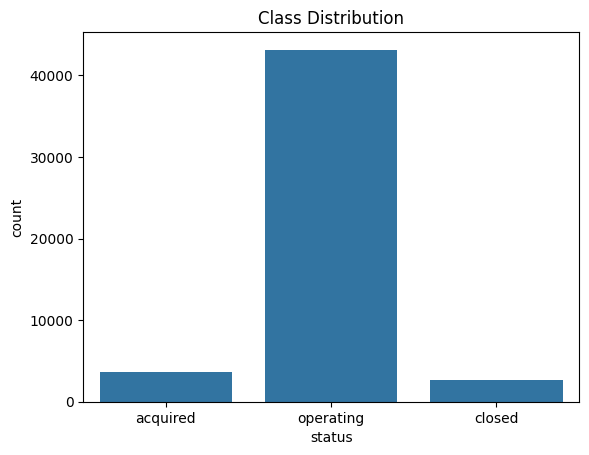

In [15]:
#visulaize distribution
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='status', data=df)
plt.title('Class Distribution')
plt.show()

In [16]:
#correlation analysis
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()
display(correlation_matrix.head())

,funding_total_usd,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
funding_total_usd,1.000000,0.109418,-0.065528,-0.000814,0.208773,-0.001117,0.022715,0.011837,0.903473,0.003924,...,0.036822,0.003057,0.059339,0.102648,0.130636,0.125974,0.114232,0.091943,0.082794,0.069429
funding_rounds,0.109418,1.000000,-0.076896,0.085698,0.402428,-0.002215,0.032151,0.016727,0.020536,0.058851,...,0.013368,0.015490,0.165752,0.278807,0.298557,0.200275,0.203276,0.104723,0.059684,0.035165
founded_year,-0.065528,-0.076896,1.000000,0.052489,-0.093062,0.004754,-0.021179,-0.008993,-0.024903,0.011018,...,-0.002588,-0.001478,-0.017499,-0.046055,-0.050062,-0.032341,-0.030931,-0.011240,-0.004066,-0.001099
seed,-0.000814,0.085698,0.052489,1.000000,-0.011538,-0.003869,-0.004652,-0.001362,-0.002338,-0.002691,...,-0.001951,0.203606,0.014266,0.001645,-0.000901,-0.007789,-0.010666,-0.005288,-0.002043,-0.001077
venture,0.208773,0.402428,-0.093062,-0.011538,1.000000,-0.007326,0.008731,0.000782,0.008727,0.005443,...,0.064629,-0.003084,0.325405,0.495186,0.575145,0.588288,0.528459,0.427673,0.418681,0.373413


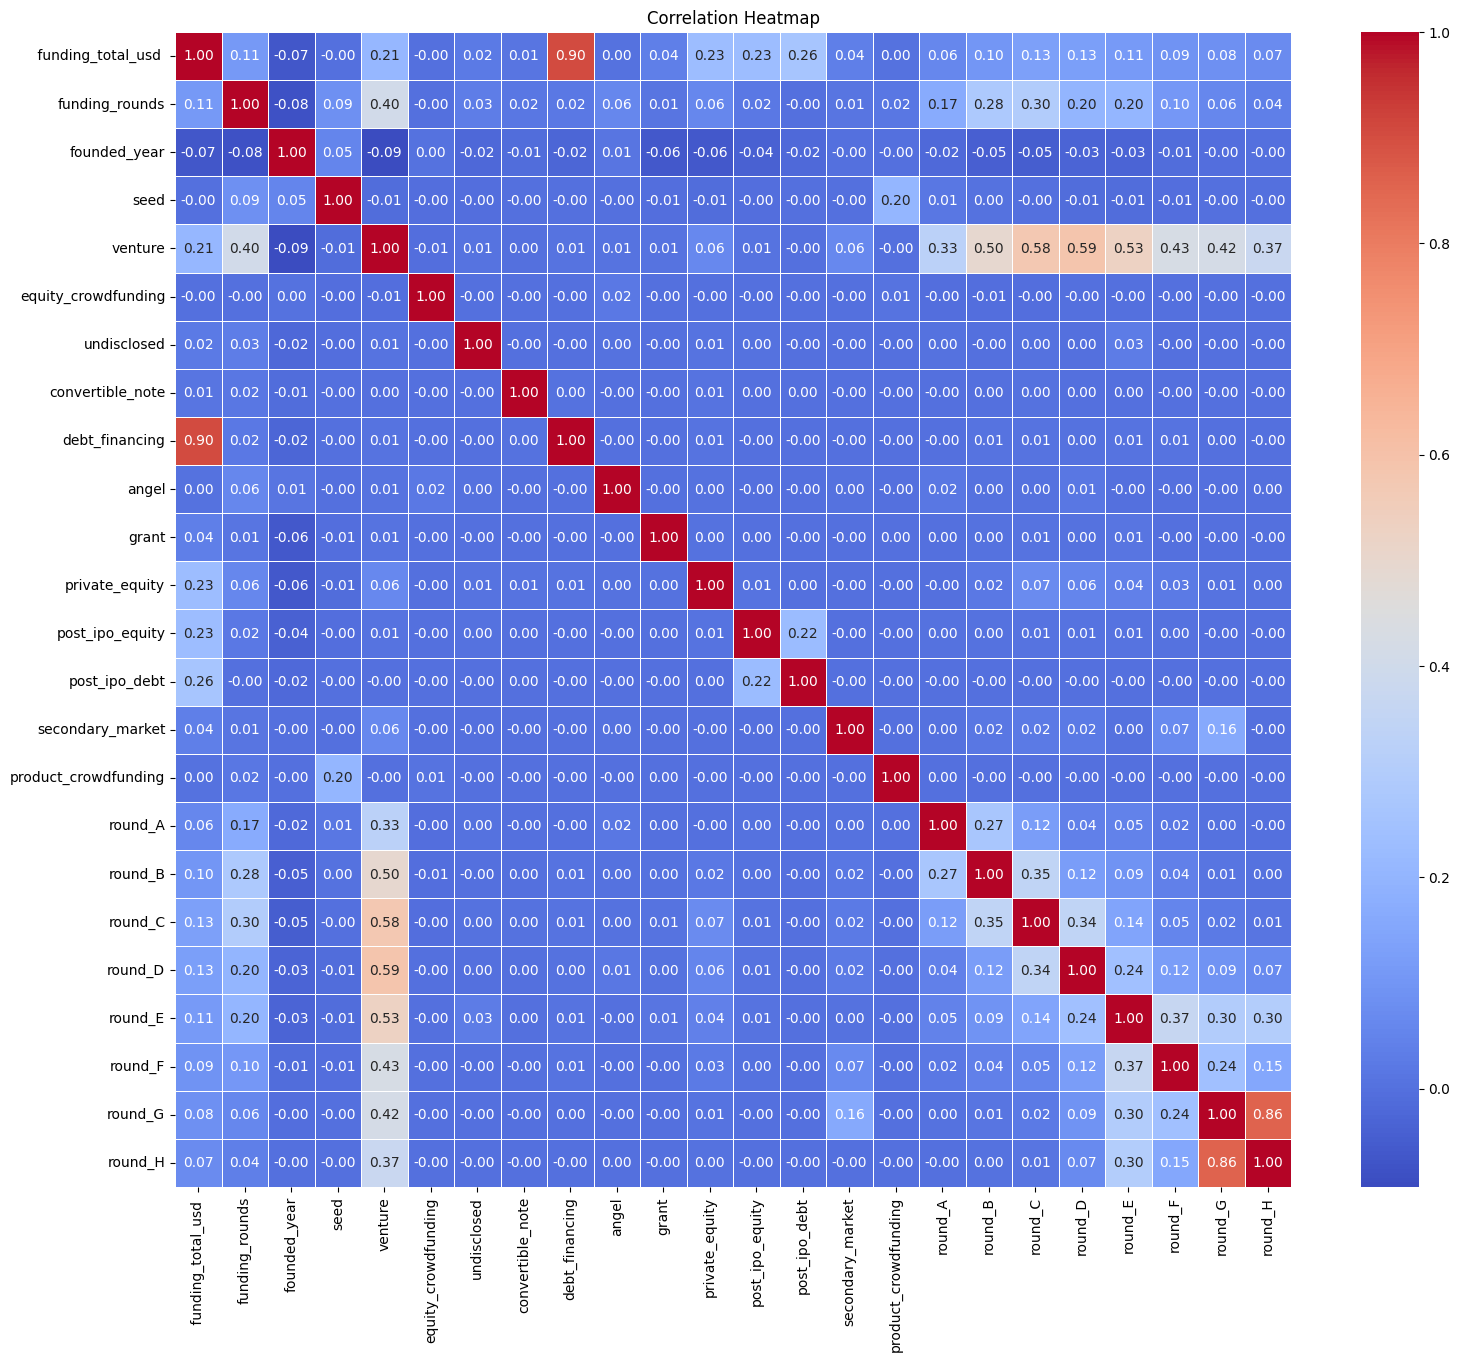

In [17]:
plt.figure(figsize=(18,15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
)
plt.title('Correlation Heatmap')
plt.show()

# **Classification Task**

In [18]:
#Splitting data into train and test
X = df.drop('status',axis=1)
y= df['status']

# Select only numeric columns for X before splitting
X_numeric = X.select_dtypes(include=np.number)

X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
import sys
!{sys.executable} -m pip install imbalanced-learn

  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)

   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
#Handle imbalance using SMOTE
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [25]:
#Logistic Regression
logistic = LogisticRegression()
logistic.fit(X_train_resampled, y_train_resampled)
y_pred_logistic = logistic.predict(X_test_scaled)

In [26]:
#Random Forest
rf = RandomForestClassifier()
rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = rf.predict(X_test_scaled)

In [27]:
#Evaluate Classification models
logistic_f1 = f1_score(y_test, y_pred_logistic, average='weighted')
logistic_precision = precision_score(y_test, y_pred_logistic, average='weighted')
logistic_recall = recall_score(y_test, y_pred_logistic, average='weighted')

rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')

In [28]:
classification_model = []
classification_model.append(['Logistic Regression', logistic_f1, logistic_precision, logistic_recall])
classification_model.append(['Random Forest', rf_f1, rf_precision, rf_recall])

In [29]:
#Compare Classification Models
classification_df = pd.DataFrame(classification_model, columns=['Model', 'F1 Score', 'Precision', 'Recall'])
classification_df

,Model,F1 Score,Precision,Recall
0,Logistic Regression,0.397924,0.815709,0.315939
1,Random Forest,0.690927,0.800578,0.622573


# **Regression Task**

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [31]:
# Predict Funding Amount

y_reg = df[' funding_total_usd ']

# Splitting data into training and testing sets for regression
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_numeric, y_reg, test_size=0.2, random_state=42, stratify = y)

# Scale the features for regression
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

In [33]:
#Linear Regression
linear_reg = LinearRegression()
linear_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_linear_reg = linear_reg.predict(X_test_reg_scaled)

In [34]:
#Random Forest Regressor
rf_reg = RandomForestRegressor(random_state=42)
rf_reg.fit(X_train_reg_scaled, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_reg_scaled)

In [35]:
# Evaluate Regression Models
linear_mse = mean_squared_error(y_test_reg, y_pred_linear_reg)
linear_r2 = r2_score(y_test_reg, y_pred_linear_reg)

rf_mse = mean_squared_error(y_test_reg, y_pred_rf_reg)
rf_r2 = r2_score(y_test_reg, y_pred_rf_reg)

# **Clustering Task**

In [36]:
# K-means Clustering
from sklearn.cluster import KMeans

In [37]:
X_scaled_for_clustering = X_train_reg_scaled

wcss = [] # Within-cluster sum of squares

# Try different numbers of clusters from 1 to 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X_scaled_for_clustering)
    wcss.append(kmeans.inertia_)

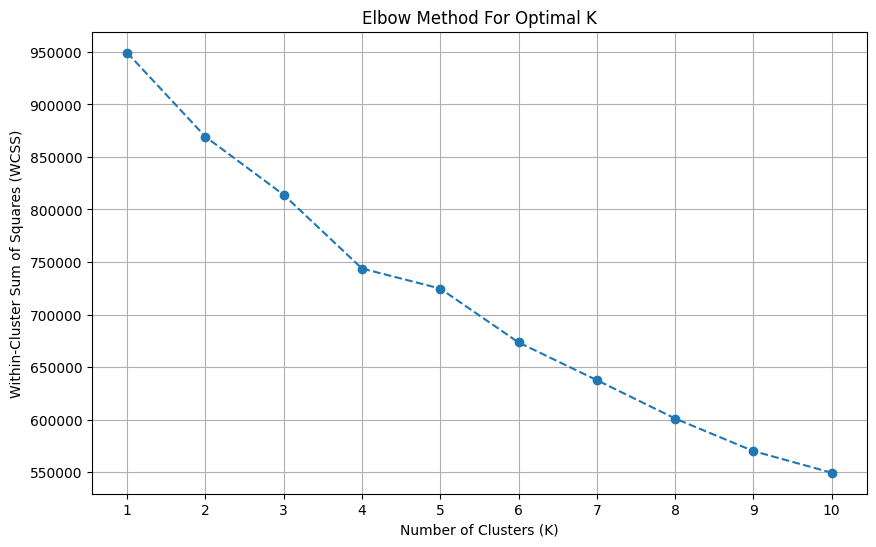

In [38]:
# Plot the elbow method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

In [39]:
# Based on the elbow method plot, the optimal number of clusters appears to be 3.
optimal_k = 3
print(f"Optimal number of clusters (K) chosen: {optimal_k}")

Optimal number of clusters (K) chosen: 3


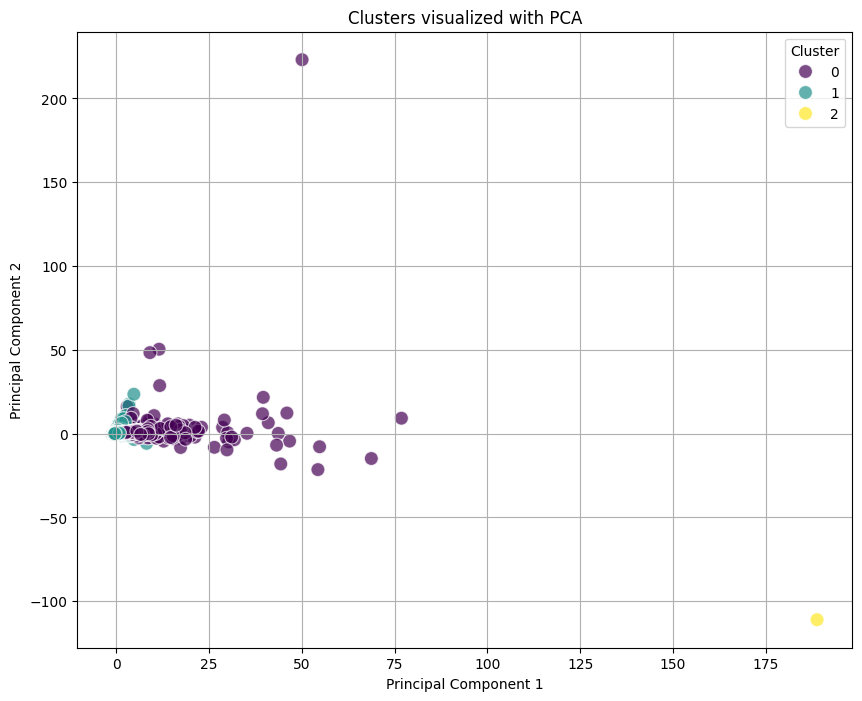

In [40]:
from sklearn.decomposition import PCA

# Apply K-Means with the chosen optimal K
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_scaled_for_clustering)

# Apply PCA for dimensionality reduction to 2 components for visualization
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled_for_clustering)
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['cluster'] = cluster_labels

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='PC1', y='PC2', hue='cluster', data=pca_df, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters visualized with PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [41]:
# Add cluster labels to the original (unscaled) training data
X_train_reg_with_clusters = X_train_reg.copy()
X_train_reg_with_clusters['cluster'] = cluster_labels # cluster_labels are derived from X_scaled_for_clustering which corresponds to X_train_reg

# Calculate the mean of each feature for each cluster
cluster_means = X_train_reg_with_clusters.groupby('cluster').mean()
print("Mean values of features per cluster:")
display(cluster_means)

Mean values of features per cluster:


,funding_total_usd,funding_rounds,founded_year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.469345e+08,4.978822,2005.500331,238969.076109,9.155586e+07,651.886168,273704.986764,278580.986764,2.611333e+07,86487.522171,...,992557.213766,0.000000,9.260806e+06,1.984032e+07,2.339844e+07,1.556815e+07,7.943402e+06,4.223422e+06,9.932353e+05,3.309067e+04
1,8.381747e+06,1.568000,2008.028577,218666.802350,4.233964e+06,7059.002024,116023.208849,14634.856324,1.143433e+06,65438.362752,...,10553.669848,8348.430213,9.190291e+05,7.942139e+05,3.641154e+05,1.671191e+05,5.235665e+04,1.797404e+04,5.030468e+03,1.409154e+03
2,2.351140e+09,11.000000,2007.000000,0.000000,2.351000e+09,0.000000,0.000000,0.000000,0.000000e+00,140000.000000,...,0.000000,0.000000,1.000000e+06,1.000000e+07,2.000000e+07,1.500000e+08,3.600000e+08,2.100000e+08,1.000000e+09,6.000000e+08


In [42]:
import joblib

#Export the Random Forest classifier and the Scaler
joblib.dump(rf,'rf_model.pkl')
joblib.dump(scaler,'scaler.pkl')

print("Model saved successfully!")

Model saved successfully!
